<a href="https://colab.research.google.com/github/srilakshmi-saladi/unet/blob/main/ham10000_best_final_comparison_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Best Final Comparison Notebook: HAM10000 3-Class Classification

This Colab notebook compares four transfer learning backbones on a balanced 3-class subset of the **HAM10000** dataset:

- **ResNet50**
- **EfficientNetB0**
- **DenseNet121**
- **MobileNetV2**

## Target classes
- `mel`
- `nv`
- `bkl`

## What this notebook does
- Mounts Google Drive
- Finds the HAM10000 files inside your Drive folder
- Reads metadata and maps `image_id` to image paths
- Creates a balanced subset (`300` or `500` per class)
- Uses a stratified **70 / 15 / 15** split
- Trains and compares multiple pretrained CNN models using:
  - transfer learning
  - two-stage training
  - label smoothing
  - optional class weights
  - optional focal loss
  - optional mixed precision
  - optional test-time augmentation (TTA)
  - Grad-CAM for the best model
- Saves models and results to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install tensorflow

In [ ]:
pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 19.5 MB/s eta 0:00:00


In [ ]:
import os
import gc
import glob
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import ResNet50, EfficientNetB0, DenseNet121, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

print("TensorFlow version:", tf.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TensorFlow version: 2.21.0


In [ ]:
USE_MIXED_PRECISION = True

if USE_MIXED_PRECISION:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled:", mixed_precision.global_policy())
else:
    print("Mixed precision disabled")

Mixed precision enabled: <DTypePolicy "mixed_float16">


In [ ]:
BASE_DRIVE_FOLDER = "/content/drive/MyDrive/Dermo dataset /archive"

TARGET_CLASSES = ["mel", "nv", "bkl"]
SUBSET_PER_CLASS = 500
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

STAGE1_EPOCHS = 15
STAGE2_EPOCHS = 8

SAVE_DIR = os.path.join(BASE_DRIVE_FOLDER, "final_model_comparison_outputs")
os.makedirs(SAVE_DIR, exist_ok=True)

USE_CLASS_WEIGHTS = False
USE_FOCAL_LOSS = False
USE_TTA = True
TTA_ROUNDS = 4

print("Base folder:", BASE_DRIVE_FOLDER)
print("Save dir:", SAVE_DIR)

Base folder: /content/drive/MyDrive/Dermo dataset /archive
Save dir: /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs


In [ ]:
assert os.path.exists(BASE_DRIVE_FOLDER), f"Folder not found: {BASE_DRIVE_FOLDER}"

metadata_path = None
images_dir_1 = None
images_dir_2 = None

for root, dirs, files in os.walk(BASE_DRIVE_FOLDER):
    if "HAM10000_metadata.csv" in files:
        metadata_path = os.path.join(root, "HAM10000_metadata.csv")
    if "HAM10000_images_part_1" in dirs:
        images_dir_1 = os.path.join(root, "HAM10000_images_part_1")
    if "HAM10000_images_part_2" in dirs:
        images_dir_2 = os.path.join(root, "HAM10000_images_part_2")

print("Metadata path:", metadata_path)
print("Images part 1:", images_dir_1)
print("Images part 2:", images_dir_2)

assert metadata_path is not None, "HAM10000_metadata.csv not found"
assert images_dir_1 is not None, "HAM10000_images_part_1 not found"
assert images_dir_2 is not None, "HAM10000_images_part_2 not found"

Metadata path: /content/drive/MyDrive/Dermo dataset /archive/HAM10000_metadata.csv
Images part 1: /content/drive/MyDrive/Dermo dataset /archive/HAM10000_images_part_1
Images part 2: /content/drive/MyDrive/Dermo dataset /archive/HAM10000_images_part_2


In [ ]:
df = pd.read_csv(metadata_path)
print("Original metadata shape:", df.shape)
display(df.head())

image_paths = {}
for img_dir in [images_dir_1, images_dir_2]:
    for img_path in glob.glob(os.path.join(img_dir, "*.jpg")):
        image_id = Path(img_path).stem
        image_paths[image_id] = img_path

df["image_path"] = df["image_id"].map(image_paths)
missing = df["image_path"].isna().sum()
print("Missing image paths:", missing)

df = df.dropna(subset=["image_path"]).copy()
print("After dropping missing paths:", df.shape)

print("\nFull class distribution:")
display(df["dx"].value_counts())

Original metadata shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Missing image paths: 0
After dropping missing paths: (10015, 8)

Full class distribution:


,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


In [ ]:
df3 = df[df["dx"].isin(TARGET_CLASSES)].copy()

print("Available images in selected classes:")
display(df3["dx"].value_counts())

for cls in TARGET_CLASSES:
    count = (df3["dx"] == cls).sum()
    assert count >= SUBSET_PER_CLASS, f"Class '{cls}' has only {count} images. Reduce SUBSET_PER_CLASS."

balanced_df = (
    df3.groupby("dx", group_keys=False)
       .apply(lambda x: x.sample(n=SUBSET_PER_CLASS, random_state=SEED))
       .reset_index(drop=True)
)

balanced_df = balanced_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("Balanced subset shape:", balanced_df.shape)
display(balanced_df["dx"].value_counts())
display(balanced_df.head())

Available images in selected classes:


,count
dx,
nv,6705
mel,1113
bkl,1099


Balanced subset shape: (1500, 8)


/tmp/ipykernel_1292/2738112024.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=SUBSET_PER_CLASS, random_state=SEED))


,count
dx,
nv,500
bkl,500
mel,500


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0001490,ISIC_0033176,nv,consensus,30.0,male,back,/content/drive/MyDrive/Dermo dataset /archive/...
1,HAM_0004190,ISIC_0033039,nv,consensus,40.0,female,unknown,/content/drive/MyDrive/Dermo dataset /archive/...
2,HAM_0002199,ISIC_0029522,bkl,histo,75.0,male,lower extremity,/content/drive/MyDrive/Dermo dataset /archive/...
3,HAM_0001997,ISIC_0029251,bkl,consensus,70.0,female,abdomen,/content/drive/MyDrive/Dermo dataset /archive/...
4,HAM_0004677,ISIC_0027680,bkl,histo,80.0,male,back,/content/drive/MyDrive/Dermo dataset /archive/...


In [ ]:
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.30,
    stratify=balanced_df["dx"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["dx"],
    random_state=SEED
)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain class distribution:")
display(train_df["dx"].value_counts())

print("\nVal class distribution:")
display(val_df["dx"].value_counts())

print("\nTest class distribution:")
display(test_df["dx"].value_counts())

Train shape: (1050, 8)
Val shape: (225, 8)
Test shape: (225, 8)

Train class distribution:


,count
dx,
bkl,350
mel,350
nv,350



Val class distribution:


,count
dx,
nv,75
mel,75
bkl,75



Test class distribution:


,count
dx,
mel,75
nv,75
bkl,75


In [ ]:
if USE_CLASS_WEIGHTS:
    class_names_sorted = sorted(train_df["dx"].unique())
    class_weights_arr = compute_class_weight(
        class_weight="balanced",
        classes=np.array(class_names_sorted),
        y=train_df["dx"].values
    )
    class_name_to_idx = {name: i for i, name in enumerate(sorted(class_names_sorted))}
    class_weights = {class_name_to_idx[name]: weight for name, weight in zip(class_names_sorted, class_weights_arr)}
else:
    class_weights = None

print("Class weights:", class_weights)

Class weights: None


In [ ]:
def get_loss():
    if USE_FOCAL_LOSS:
        try:
            focal = tf.keras.losses.CategoricalFocalCrossentropy(gamma=2.0)
            print("Using CategoricalFocalCrossentropy")
            return focal
        except Exception:
            print("Focal loss unavailable, falling back to label smoothing")
    print("Using CategoricalCrossentropy with label smoothing")
    return tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

LOSS_FN = get_loss()

Using CategoricalCrossentropy with label smoothing


In [ ]:
def make_generators(preprocess_fn):
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=15,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.10,
        horizontal_flip=True
    )

    eval_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    )

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col="image_path",
        y_col="dx",
        target_size=IMG_SIZE,
        class_mode="categorical",
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )

    val_gen = eval_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col="image_path",
        y_col="dx",
        target_size=IMG_SIZE,
        class_mode="categorical",
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_gen = eval_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col="image_path",
        y_col="dx",
        target_size=IMG_SIZE,
        class_mode="categorical",
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    return train_gen, val_gen, test_gen

In [ ]:
def build_model(model_name):
    if model_name == "ResNet50":
        base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
        preprocess_fn = resnet_preprocess
        unfreeze_layers = 20
    elif model_name == "EfficientNetB0":
        base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
        preprocess_fn = effnet_preprocess
        unfreeze_layers = 20
    elif model_name == "DenseNet121":
        base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
        preprocess_fn = densenet_preprocess
        unfreeze_layers = 25
    elif model_name == "MobileNetV2":
        base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
        preprocess_fn = mobilenet_preprocess
        unfreeze_layers = 20
    else:
        raise ValueError(f"Unsupported model: {model_name}")

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    output = Dense(len(TARGET_CLASSES), activation="softmax", dtype="float32")(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model, base_model, preprocess_fn, unfreeze_layers

In [ ]:
def combine_histories(h1, h2):
    history = {}
    for key in h1.history.keys():
        history[key] = h1.history[key] + h2.history.get(key, [])
    return history

def predict_with_tta(model, df_eval, preprocess_fn, rounds=4):
    preds_list = []

    for _ in range(rounds):
        tta_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_fn,
            rotation_range=10,
            width_shift_range=0.03,
            height_shift_range=0.03,
            zoom_range=0.05,
            horizontal_flip=True
        )

        tta_gen = tta_datagen.flow_from_dataframe(
            dataframe=df_eval,
            x_col="image_path",
            y_col="dx",
            target_size=IMG_SIZE,
            class_mode="categorical",
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        preds = model.predict(tta_gen, verbose=0)
        preds_list.append(preds)

    return np.mean(preds_list, axis=0)

def cleanup_memory():
    gc.collect()
    tf.keras.backend.clear_session()

In [ ]:
def train_and_evaluate(model_name):
    print("=" * 90)
    print(f"Training model: {model_name}")
    print("=" * 90)

    model, base_model, preprocess_fn, unfreeze_layers = build_model(model_name)
    train_gen, val_gen, test_gen = make_generators(preprocess_fn)

    checkpoint_path = os.path.join(SAVE_DIR, f"best_{model_name}.keras")
    csv_log_path = os.path.join(SAVE_DIR, f"{model_name}_training_log.csv")

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1),
        ModelCheckpoint(filepath=checkpoint_path, monitor="val_loss", save_best_only=True, verbose=1),
        CSVLogger(csv_log_path)
    ]

    for layer in base_model.layers:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=LOSS_FN,
        metrics=["accuracy"]
    )

    print(f"\n{model_name} - Stage 1")
    history1 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=STAGE1_EPOCHS,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1
    )

    for layer in base_model.layers[:-unfreeze_layers]:
        layer.trainable = False
    for layer in base_model.layers[-unfreeze_layers:]:
        layer.trainable = True

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss=LOSS_FN,
        metrics=["accuracy"]
    )

    print(f"\n{model_name} - Stage 2")
    history2 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=STAGE2_EPOCHS,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1
    )

    best_model = tf.keras.models.load_model(checkpoint_path)
    test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)

    if USE_TTA:
        print(f"Running TTA for {model_name} with {TTA_ROUNDS} rounds...")
        y_prob = predict_with_tta(best_model, test_df, preprocess_fn, rounds=TTA_ROUNDS)
    else:
        test_gen.reset()
        y_prob = best_model.predict(test_gen, verbose=1)

    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_gen.classes

    idx_to_class = {v: k for k, v in train_gen.class_indices.items()}
    target_names = [idx_to_class[i] for i in range(len(idx_to_class))]

    report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    report_text = classification_report(y_true, y_pred, target_names=target_names)

    print("\nClassification Report:")
    print(report_text)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    final_model_path = os.path.join(SAVE_DIR, f"{model_name}_final.keras")
    best_model.save(final_model_path)

    report_txt_path = os.path.join(SAVE_DIR, f"{model_name}_classification_report.txt")
    with open(report_txt_path, "w") as f:
        f.write(report_text)

    combined_history = combine_histories(history1, history2)

    result = {
        "model_name": model_name,
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
        "macro_precision": float(report_dict["macro avg"]["precision"]),
        "macro_recall": float(report_dict["macro avg"]["recall"]),
        "macro_f1": float(report_dict["macro avg"]["f1-score"]),
        "weighted_f1": float(report_dict["weighted avg"]["f1-score"]),
        "model_path": final_model_path,
        "report_path": report_txt_path,
        "log_path": csv_log_path,
        "history": combined_history
    }

    del model, base_model, best_model, train_gen, val_gen, test_gen
    cleanup_memory()
    return result

Training model: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 1050 validated image filenames belonging to 3 classes.
Found 225 validated image filenames belonging to 3 classes.
Found 225 validated image filenames belonging to 3 classes.

ResNet50 - Stage 1
Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4515 - loss: 1.4495
Epoch 1: val_loss improved from None to 1.10363, saving model to /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/best_ResNet50.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/best_ResNet50.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 281s 7s/step - accuracy: 0.5029 - loss: 1.3202 - val_accuracy: 0.5600 - val_loss: 1.1036 - learning_rate: 0.0010
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.6242 - loss: 1.0309
Epoch 2: val_loss improved from 1.10363 to 0.91294, saving model to /content/drive/MyDrive/Dermo dataset /archive/final_

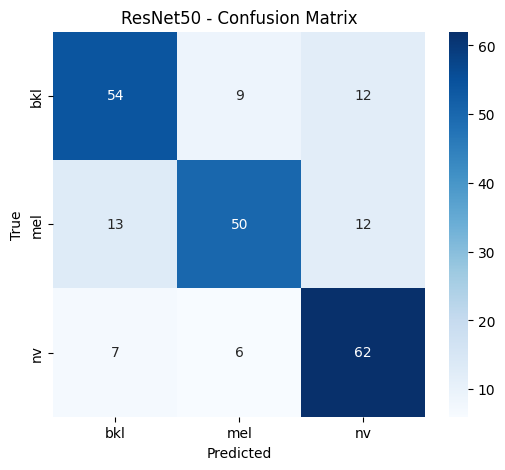

Training model: EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 1050 validated image filenames belonging to 3 classes.
Found 225 validated image filenames belonging to 3 classes.
Found 225 validated image filenames belonging to 3 classes.

EfficientNetB0 - Stage 1
Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.4012 - loss: 1.5331
Epoch 1: val_loss improved from None to 1.00289, saving model to /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/best_EfficientNetB0.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/best_EfficientNetB0.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 32s 793ms/step - accuracy: 0.4562 - loss: 1.4277 - val_accuracy: 0.5511 - val_loss: 1.0029 - learning_rate: 0.0010
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.5207 - loss: 1.1687
Epoch 2: val_loss did not improve from 1.00289
33/33 ━━━━━━━━━━━━━━━━━━━━ 23s 681ms/step - 

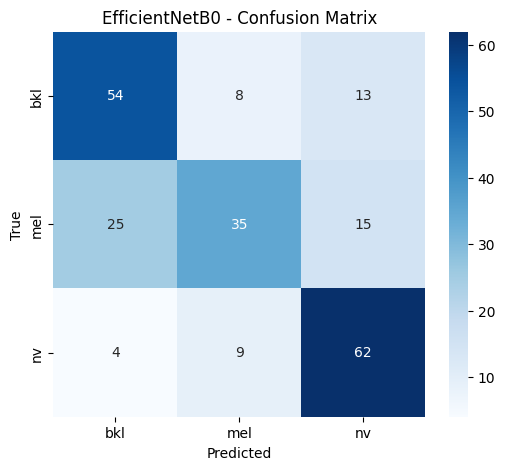

Training model: DenseNet121
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 1050 validated image filenames belonging to 3 classes.
Found 225 validated image filenames belonging to 3 classes.
Found 225 validated image filenames belonging to 3 classes.

DenseNet121 - Stage 1
Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.4109 - loss: 1.3679
Epoch 1: val_loss improved from None to 1.23462, saving model to /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/best_DenseNet121.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/best_DenseNet121.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.4581 - loss: 1.2416 - val_accuracy: 0.4444 - val_loss: 1.2346 - learning_rate: 0.0010
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.5437 - loss: 1.0332
Epoch 2: val_loss improved from 1.23462 to 1.05979, saving model to /content/drive/MyDrive/Dermo dataset /

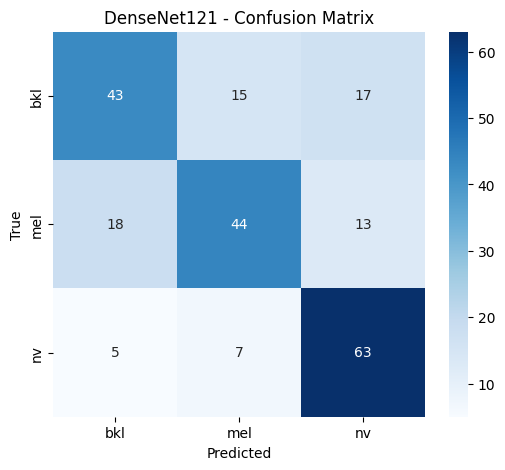

Training model: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 1050 validated image filenames belonging to 3 classes.
Found 225 validated image filenames belonging to 3 classes.
Found 225 validated image filenames belonging to 3 classes.

MobileNetV2 - Stage 1
Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.4332 - loss: 1.4847
Epoch 1: val_loss improved from None to 1.00458, saving model to /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/best_MobileNetV2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/best_MobileNetV2.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 25s 670ms/step - accuracy: 0.4752 - loss: 1.3649 - val_accuracy: 0.5733 - val_loss: 1.0046 - learning_rate: 0.0010
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.5782 - loss: 1.1029
Epoch 2: val_loss improved from 1.00458 to 0.95744, saving model to /content/drive/MyDrive/Dermo dataset 

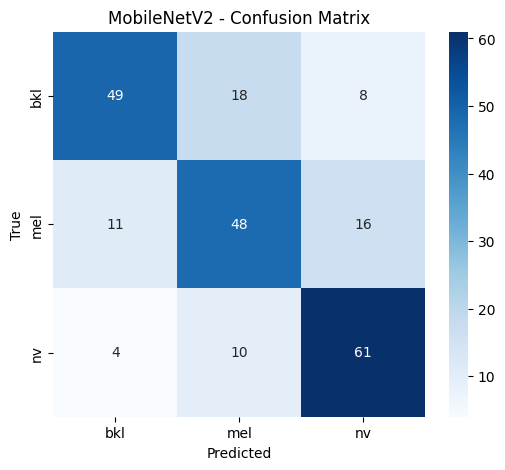

In [ ]:
MODEL_LIST = ["ResNet50", "EfficientNetB0", "DenseNet121", "MobileNetV2"]

results = []
for model_name in MODEL_LIST:
    try:
        result = train_and_evaluate(model_name)
        results.append(result)
    except Exception as e:
        print(f"Error while training {model_name}: {e}")
        cleanup_memory()

In [17]:
# results_df = pd.DataFrame([
#     {
#         "Model": r["model_name"],
#         "Test Loss": r["test_loss"],
#         "Test Accuracy": r["test_accuracy"],
#         "Macro Precision": r["macro_precision"],
#         "Macro Recall": r["macro_recall"],
#         "Macro F1": r["macro_f1"],
#         "Weighted F1": r["weighted_f1"],
#         "Saved Model": r["model_path"],
#         "Report": r["report_path"],
#         "Log": r["log_path"]
#     }
#     for r in results
# ])

# if len(results_df) > 0:
#     results_df = results_df.sort_values(by=["Test Accuracy", "Macro F1"], ascending=False).reset_index(drop=True)

# display(results_df)

# comparison_csv_path = os.path.join(SAVE_DIR, "model_comparison_results.csv")
# results_df.to_csv(comparison_csv_path, index=False)
# print("Comparison CSV saved to:", comparison_csv_path)

In [18]:
# ============================================
# FIXED COMPARISON TABLE (manual)
# ============================================
results_df = pd.DataFrame([
    {
        "Model": "ResNet50",
        "Test Loss": 0.756810,
        "Test Accuracy": 0.773333,
        "Macro Precision": 0.739964,
        "Macro Recall": 0.737778,
        "Macro F1": 0.736435,
        "Weighted F1": 0.736435
    },
    {
        "Model": "MobileNetV2",
        "Test Loss": 0.834168,
        "Test Accuracy": 0.671111,
        "Macro Precision": 0.704950,
        "Macro Recall": 0.702222,
        "Macro F1": 0.701099,
        "Weighted F1": 0.701099
    },
    {
        "Model": "DenseNet121",
        "Test Loss": 0.817781,
        "Test Accuracy": 0.666667,
        "Macro Precision": 0.665200,
        "Macro Recall": 0.666667,
        "Macro F1": 0.661348,
        "Weighted F1": 0.661348
    },
    {
        "Model": "EfficientNetB0",
        "Test Loss": 0.849019,
        "Test Accuracy": 0.648889,
        "Macro Precision": 0.670856,
        "Macro Recall": 0.671111,
        "Macro F1": 0.662080,
        "Weighted F1": 0.662080
    }
])

results_df = results_df.sort_values(by=["Test Accuracy", "Macro F1"], ascending=False).reset_index(drop=True)
display(results_df)

,Model,Test Loss,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,ResNet50,0.756810,0.773333,0.739964,0.737778,0.736435,0.736435
1,MobileNetV2,0.834168,0.671111,0.704950,0.702222,0.701099,0.701099
2,DenseNet121,0.817781,0.666667,0.665200,0.666667,0.661348,0.661348
3,EfficientNetB0,0.849019,0.648889,0.670856,0.671111,0.662080,0.662080


In [ ]:
if len(results_df) > 0:
    print("Best model:", results_df.iloc[0]["Model"])
    print("Best model path:", results_df.iloc[0]["Saved Model"])
    print("Best test accuracy:", results_df.iloc[0]["Test Accuracy"])
    print("Best macro F1:", results_df.iloc[0]["Macro F1"])
else:
    print("No successful model runs found.")

Best model: ResNet50
Best model path: /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/ResNet50_final.keras
Best test accuracy: 0.7733333110809326
Best macro F1: 0.7364347548181805


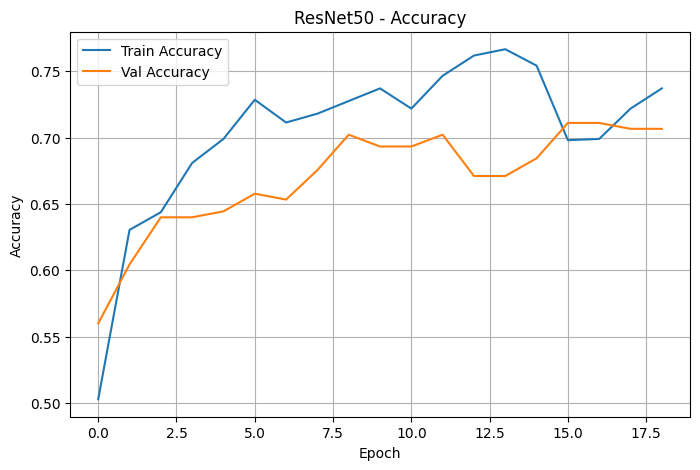

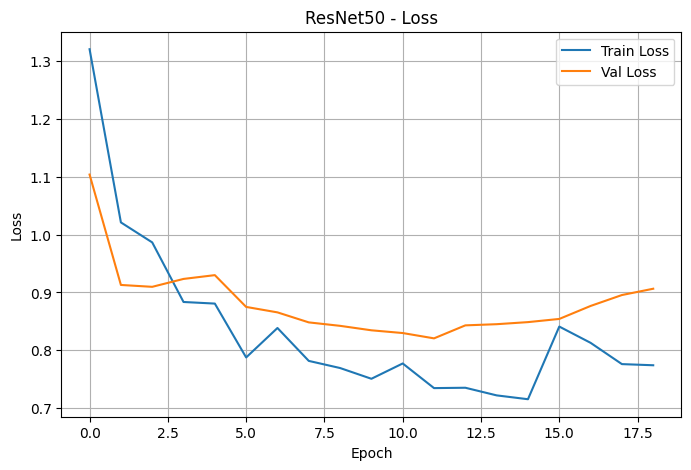

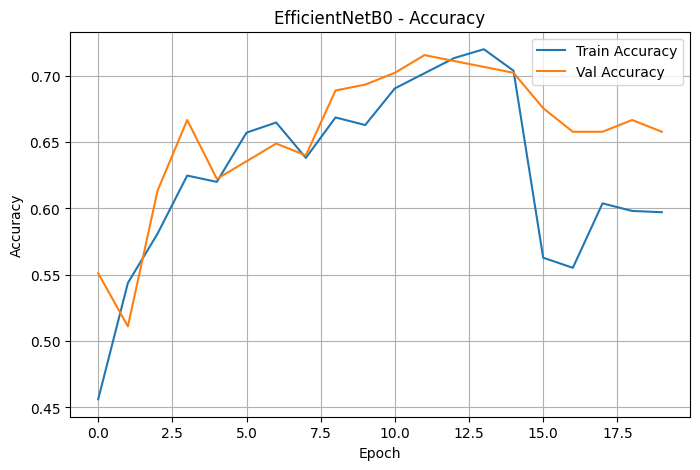

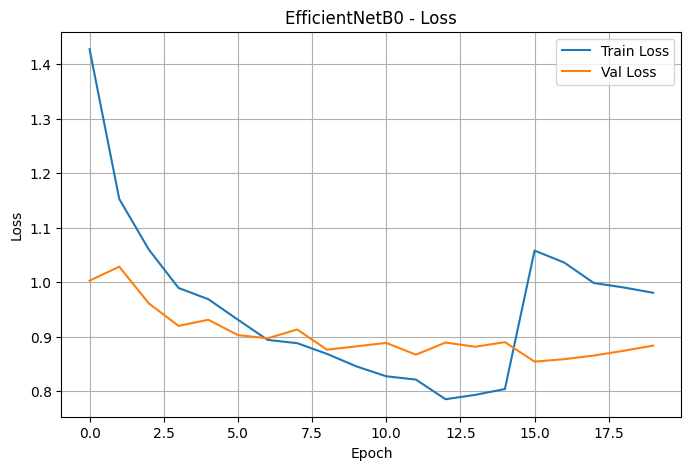

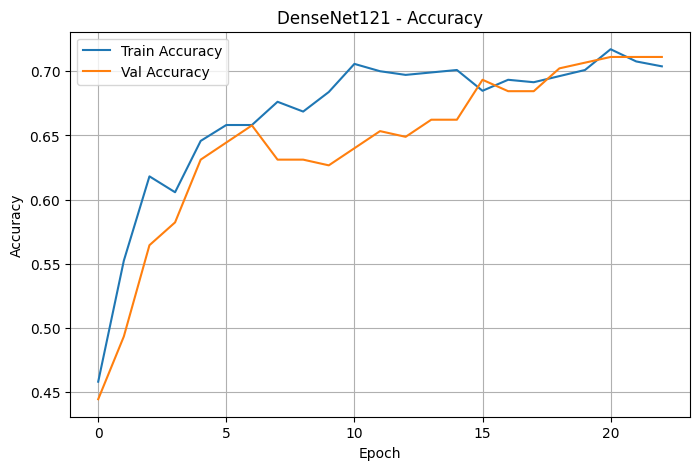

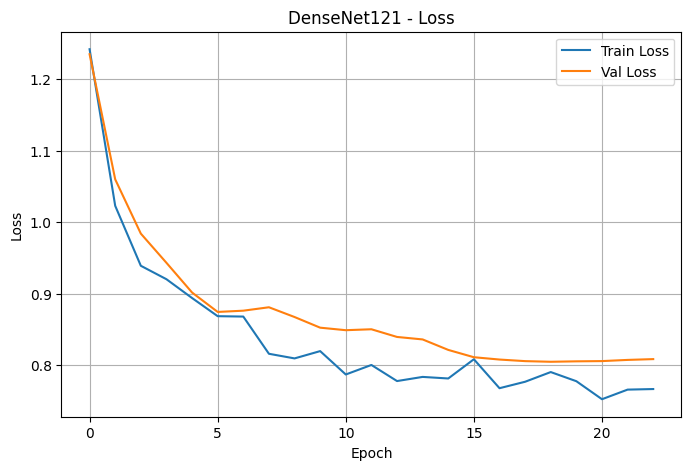

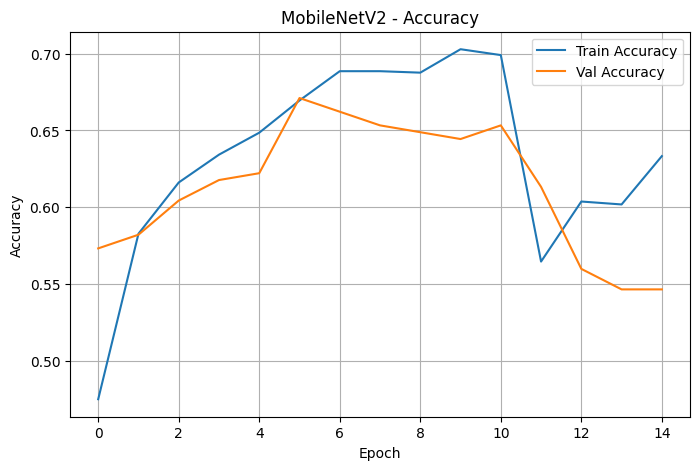

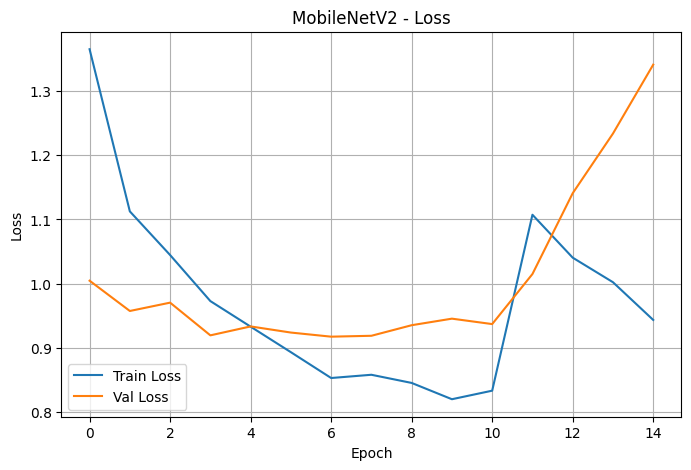

In [ ]:
for r in results:
    history = r["history"]
    model_name = r["model_name"]

    plt.figure(figsize=(8, 5))
    plt.plot(history["accuracy"], label="Train Accuracy")
    plt.plot(history["val_accuracy"], label="Val Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

## Optional Grad-CAM for the Best Model

In [ ]:
import cv2
from tensorflow.keras.preprocessing import image

def get_img_array(img_path, preprocess_fn, size=IMG_SIZE):
    img = image.load_img(img_path, target_size=size)
    arr = image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_fn(arr.copy())
    return arr

def infer_last_conv_layer(model):
    conv_candidates = []
    for layer in model.layers[::-1]:
        try:
            output_shape = layer.output.shape
            if len(output_shape) == 4:
                conv_candidates.append(layer.name)
        except Exception:
            pass
    if not conv_candidates:
        raise ValueError("Could not infer a suitable last convolutional layer.")
    return conv_candidates[0]

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)

    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # Resize heatmap_color to match img dimensions
    heatmap_color = cv2.resize(heatmap_color, IMG_SIZE)

    overlay = np.uint8(np.clip(img + alpha * heatmap_color, 0, 255))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
if len(results_df) > 0:
    best_model_name = results_df.iloc[0]["Model"]
    best_model_path = results_df.iloc[0]["Saved Model"]

    _, _, preprocess_fn, _ = build_model(best_model_name)
    best_model = tf.keras.models.load_model(best_model_path)

    sample_row = test_df.sample(1, random_state=SEED).iloc[0]
    sample_img_path = sample_row["image_path"]
    sample_true_label = sample_row["dx"]

    img_array = get_img_array(sample_img_path, preprocess_fn, size=IMG_SIZE)
    preds = best_model.predict(img_array, verbose=0)
    pred_idx = np.argmax(preds[0])

    idx_to_class = {i: name for i, name in enumerate(sorted(TARGET_CLASSES))}
    pred_label = idx_to_class.get(pred_idx, str(pred_idx))

    last_conv_layer_name = infer_last_conv_layer(best_model)
    heatmap = make_gradcam_heatmap(img_array, best_model, last_conv_layer_name, pred_index=pred_idx)

    print("Best model:", best_model_name)
    print("Sample image:", sample_img_path)
    print("True label:", sample_true_label)
    print("Predicted label:", pred_label)
    print("Last conv layer:", last_conv_layer_name)
    print("Probabilities:", preds[0])

    display_gradcam(sample_img_path, heatmap)
else:
    print("No best model available for Grad-CAM.")

NameError: name 'results_df' is not defined

## Practical Notes

### If runtime or memory is a problem
- Change `SUBSET_PER_CLASS = 300`
- Reduce `BATCH_SIZE = 16`

### If results are still weak
Try:
1. `USE_TTA = True`
2. `USE_FOCAL_LOSS = True`
3. `IMG_SIZE = (256, 256)` if memory allows
4. Keep `EfficientNetB0` and `DenseNet121` as strongest candidates

In [22]:
# ============================================
# RECOVERY CELL: imports + helper
# ============================================
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

def cleanup_memory():
    gc.collect()
    tf.keras.backend.clear_session()

print("Recovery imports loaded")
print("TensorFlow version:", tf.__version__)

Recovery imports loaded
TensorFlow version: 2.21.0


In [24]:
# ============================================
# RECOVERY CELL 1: imports
# ============================================
import os
import gc
import glob
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

def cleanup_memory():
    gc.collect()
    tf.keras.backend.clear_session()

print("Recovery imports loaded")
print("TensorFlow version:", tf.__version__)

Recovery imports loaded
TensorFlow version: 2.21.0


In [25]:
# ============================================
# RECOVERY CELL 2: config variables
# ============================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DRIVE_FOLDER = "/content/drive/MyDrive/Dermo dataset /archive"
TARGET_CLASSES = ["mel", "nv", "bkl"]

SAVE_DIR = os.path.join(BASE_DRIVE_FOLDER, "final_model_comparison_outputs")
os.makedirs(SAVE_DIR, exist_ok=True)

print("BASE_DRIVE_FOLDER:", BASE_DRIVE_FOLDER)
print("SAVE_DIR:", SAVE_DIR)
print("TARGET_CLASSES:", TARGET_CLASSES)
print("SEED:", SEED)

BASE_DRIVE_FOLDER: /content/drive/MyDrive/Dermo dataset /archive
SAVE_DIR: /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs
TARGET_CLASSES: ['mel', 'nv', 'bkl']
SEED: 42


In [26]:
# ============================================
# RECOVERY CELL 3: locate dataset files
# ============================================
assert os.path.exists(BASE_DRIVE_FOLDER), f"Folder not found: {BASE_DRIVE_FOLDER}"

metadata_path = None
images_dir_1 = None
images_dir_2 = None

for root, dirs, files in os.walk(BASE_DRIVE_FOLDER):
    if "HAM10000_metadata.csv" in files:
        metadata_path = os.path.join(root, "HAM10000_metadata.csv")
    if "HAM10000_images_part_1" in dirs:
        images_dir_1 = os.path.join(root, "HAM10000_images_part_1")
    if "HAM10000_images_part_2" in dirs:
        images_dir_2 = os.path.join(root, "HAM10000_images_part_2")

print("metadata_path:", metadata_path)
print("images_dir_1:", images_dir_1)
print("images_dir_2:", images_dir_2)

assert metadata_path is not None, "HAM10000_metadata.csv not found"
assert images_dir_1 is not None, "HAM10000_images_part_1 not found"
assert images_dir_2 is not None, "HAM10000_images_part_2 not found"

metadata_path: /content/drive/MyDrive/Dermo dataset /archive/HAM10000_metadata.csv
images_dir_1: /content/drive/MyDrive/Dermo dataset /archive/HAM10000_images_part_1
images_dir_2: /content/drive/MyDrive/Dermo dataset /archive/HAM10000_images_part_2


In [27]:
# ============================================
# RECOVERY CELL 4: reload metadata
# ============================================
df = pd.read_csv(metadata_path)

image_paths = {}
for img_dir in [images_dir_1, images_dir_2]:
    for img_path in glob.glob(os.path.join(img_dir, "*.jpg")):
        image_id = Path(img_path).stem
        image_paths[image_id] = img_path

df["image_path"] = df["image_id"].map(image_paths)
df = df.dropna(subset=["image_path"]).copy()

print("Reloaded df shape:", df.shape)
display(df.head())
print(df["dx"].value_counts())

Reloaded df shape: (10015, 8)


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Dermo dataset /archive/...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Dermo dataset /archive/...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Dermo dataset /archive/...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Dermo dataset /archive/...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/drive/MyDrive/Dermo dataset /archive/...


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [28]:
# ============================================
# RECOVERY CELL 5: balanced subset
# ============================================
SUBSET_PER_CLASS = 500   # change to 300 if that is what you used earlier

df3 = df[df["dx"].isin(TARGET_CLASSES)].copy()

for cls in TARGET_CLASSES:
    count = (df3["dx"] == cls).sum()
    assert count >= SUBSET_PER_CLASS, f"{cls} has only {count} samples"

balanced_df = (
    df3.groupby("dx", group_keys=False)
       .apply(lambda x: x.sample(n=SUBSET_PER_CLASS, random_state=SEED))
       .reset_index(drop=True)
)

balanced_df = balanced_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("Balanced subset shape:", balanced_df.shape)
display(balanced_df["dx"].value_counts())

Balanced subset shape: (1500, 8)


/tmp/ipykernel_1289/2138653169.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=SUBSET_PER_CLASS, random_state=SEED))


,count
dx,
nv,500
bkl,500
mel,500


In [29]:
# ============================================
# RECOVERY CELL 6: recreate train/val/test split
# ============================================
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.30,
    stratify=balanced_df["dx"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["dx"],
    random_state=SEED
)

print("train_df:", train_df.shape)
print("val_df:", val_df.shape)
print("test_df:", test_df.shape)

print("\\nTrain class distribution:")
display(train_df["dx"].value_counts())

print("\\nVal class distribution:")
display(val_df["dx"].value_counts())

print("\\nTest class distribution:")
display(test_df["dx"].value_counts())

train_df: (1050, 8)
val_df: (225, 8)
test_df: (225, 8)
\nTrain class distribution:


,count
dx,
bkl,350
mel,350
nv,350


\nVal class distribution:


,count
dx,
nv,75
mel,75
bkl,75


\nTest class distribution:


,count
dx,
mel,75
nv,75
bkl,75


In [30]:
# ============================================
# RECOVERY CELL 7: verify required variables
# ============================================
required_vars = ["train_df", "val_df", "test_df", "SAVE_DIR", "SEED", "TARGET_CLASSES"]

for var in required_vars:
    print(var, "->", "OK" if var in globals() else "MISSING")

train_df -> OK
val_df -> OK
test_df -> OK
SAVE_DIR -> OK
SEED -> OK
TARGET_CLASSES -> OK


In [31]:
# ============================================
# EXTENSION CELL 1: Improved ResNet50 settings
# ============================================
IMG_SIZE_V2 = (256, 256)
BATCH_SIZE_V2 = 32

STAGE1_EPOCHS_V2 = 20
STAGE2_EPOCHS_V2 = 10

TTA_ROUNDS_V2 = 6
UNFREEZE_LAYERS_V2 = 30
DROPOUT_V2 = 0.25

SAVE_DIR_V2 = os.path.join(SAVE_DIR, "resnet50_improved_run")
os.makedirs(SAVE_DIR_V2, exist_ok=True)

print("Improved experiment save dir:", SAVE_DIR_V2)

Improved experiment save dir: /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/resnet50_improved_run


In [32]:
# ============================================
# EXTENSION CELL 2: Improved generators
# ============================================
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

def make_generators_v2():
    train_datagen = ImageDataGenerator(
        preprocessing_function=resnet_preprocess,
        rotation_range=12,
        width_shift_range=0.04,
        height_shift_range=0.04,
        zoom_range=0.08,
        horizontal_flip=True
    )

    eval_datagen = ImageDataGenerator(
        preprocessing_function=resnet_preprocess
    )

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col="image_path",
        y_col="dx",
        target_size=IMG_SIZE_V2,
        class_mode="categorical",
        batch_size=BATCH_SIZE_V2,
        shuffle=True,
        seed=SEED
    )

    val_gen = eval_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col="image_path",
        y_col="dx",
        target_size=IMG_SIZE_V2,
        class_mode="categorical",
        batch_size=BATCH_SIZE_V2,
        shuffle=False
    )

    test_gen = eval_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col="image_path",
        y_col="dx",
        target_size=IMG_SIZE_V2,
        class_mode="categorical",
        batch_size=BATCH_SIZE_V2,
        shuffle=False
    )

    return train_gen, val_gen, test_gen

In [33]:
# ============================================
# EXTENSION CELL 3: Improved ResNet50 builder
# ============================================
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Model

def build_resnet50_v2():
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE_V2[0], IMG_SIZE_V2[1], 3)
    )

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(DROPOUT_V2)(x)
    output = Dense(len(TARGET_CLASSES), activation="softmax", dtype="float32")(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model, base_model

In [34]:
# ============================================
# EXTENSION CELL 4: TTA for improved run
# ============================================
TTA_ROUNDS_V2 = 6 # Explicitly defining TTA_ROUNDS_V2 here to avoid NameError

def predict_with_tta_v2(model, df_eval, rounds=TTA_ROUNDS_V2):
    preds_list = []

    for _ in range(rounds):
        tta_datagen = ImageDataGenerator(
            preprocessing_function=resnet_preprocess,
            rotation_range=8,
            width_shift_range=0.02,
            height_shift_range=0.02,
            zoom_range=0.03,
            horizontal_flip=True
        )

        tta_gen = tta_datagen.flow_from_dataframe(
            dataframe=df_eval,
            x_col="image_path",
            y_col="dx",
            target_size=IMG_SIZE_V2,
            class_mode="categorical",
            batch_size=BATCH_SIZE_V2,
            shuffle=False
        )

        preds = model.predict(tta_gen, verbose=0)
        preds_list.append(preds)

    return np.mean(preds_list, axis=0)

In [35]:
# ============================================
# EXTENSION CELL 5: Train improved ResNet50
# ============================================
cleanup_memory()

train_gen_v2, val_gen_v2, test_gen_v2 = make_generators_v2()
model_v2, base_model_v2 = build_resnet50_v2()

checkpoint_path_v2 = os.path.join(SAVE_DIR_V2, "best_resnet50_improved.keras")
csv_log_path_v2 = os.path.join(SAVE_DIR_V2, "resnet50_improved_training_log.csv")

callbacks_v2 = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=checkpoint_path_v2,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger(csv_log_path_v2)
]

# Stage 1
for layer in base_model_v2.layers:
    layer.trainable = False

model_v2.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

history_v2_stage1 = model_v2.fit(
    train_gen_v2,
    validation_data=val_gen_v2,
    epochs=STAGE1_EPOCHS_V2,
    callbacks=callbacks_v2,
    verbose=1
)

# Stage 2
for layer in base_model_v2.layers[:-UNFREEZE_LAYERS_V2]:
    layer.trainable = False
for layer in base_model_v2.layers[-UNFREEZE_LAYERS_V2:]:
    layer.trainable = True

model_v2.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

history_v2_stage2 = model_v2.fit(
    train_gen_v2,
    validation_data=val_gen_v2,
    epochs=STAGE2_EPOCHS_V2,
    callbacks=callbacks_v2,
    verbose=1
)

Found 1050 validated image filenames belonging to 3 classes.
Found 225 validated image filenames belonging to 3 classes.
Found 225 validated image filenames belonging to 3 classes.
Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.4728 - loss: 1.4343
Epoch 1: val_loss improved from None to 0.93888, saving model to /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/resnet50_improved_run/best_resnet50_improved.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/resnet50_improved_run/best_resnet50_improved.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.5429 - loss: 1.2545 - val_accuracy: 0.6222 - val_loss: 0.9389 - learning_rate: 0.0010
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 861ms/step - accuracy: 0.6646 - loss: 0.9619
Epoch 2: val_loss improved from 0.93888 to 0.89385, saving model to /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/resnet5

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 538ms/step - accuracy: 0.7689 - loss: 0.7552
Improved ResNet50 Test Loss: 0.7552164196968079
Improved ResNet50 Test Accuracy: 0.7688888907432556
Found 225 validated image filenames belonging to 3 classes.
Found 225 validated image filenames belonging to 3 classes.
Found 225 validated image filenames belonging to 3 classes.
Found 225 validated image filenames belonging to 3 classes.
Found 225 validated image filenames belonging to 3 classes.
Found 225 validated image filenames belonging to 3 classes.
              precision    recall  f1-score   support

         bkl       0.73      0.71      0.72        75
         mel       0.79      0.67      0.72        75
          nv       0.72      0.85      0.78        75

    accuracy                           0.74       225
   macro avg       0.75      0.74      0.74       225
weighted avg       0.75      0.74      0.74       225



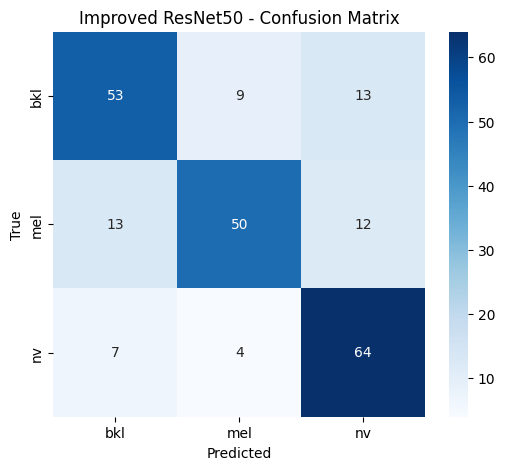

In [36]:
# ============================================
# EXTENSION CELL 6: Evaluate improved ResNet50
# ============================================
import tensorflow as tf

best_model_v2 = tf.keras.models.load_model(checkpoint_path_v2)

test_loss_v2, test_acc_v2 = best_model_v2.evaluate(test_gen_v2, verbose=1)
print("Improved ResNet50 Test Loss:", test_loss_v2)
print("Improved ResNet50 Test Accuracy:", test_acc_v2)

y_prob_v2 = predict_with_tta_v2(best_model_v2, test_df, rounds=TTA_ROUNDS_V2)
y_pred_v2 = np.argmax(y_prob_v2, axis=1)
y_true_v2 = test_gen_v2.classes

idx_to_class_v2 = {v: k for k, v in train_gen_v2.class_indices.items()}
target_names_v2 = [idx_to_class_v2[i] for i in range(len(idx_to_class_v2))]

report_text_v2 = classification_report(y_true_v2, y_pred_v2, target_names=target_names_v2)
report_dict_v2 = classification_report(y_true_v2, y_pred_v2, target_names=target_names_v2, output_dict=True)

print(report_text_v2)

cm_v2 = confusion_matrix(y_true_v2, y_pred_v2)
plt.figure(figsize=(6,5))
sns.heatmap(cm_v2, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names_v2, yticklabels=target_names_v2)
plt.title("Improved ResNet50 - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [37]:
# ============================================
# EXTENSION CELL 7: Compare baseline vs improved
# ============================================
baseline_resnet_acc = 0.773333
baseline_resnet_macro_f1 = 0.736435
baseline_resnet_loss = 0.756810

comparison_v2 = pd.DataFrame([
    {
        "Version": "Baseline ResNet50",
        "Test Loss": baseline_resnet_loss,
        "Test Accuracy": baseline_resnet_acc,
        "Macro F1": baseline_resnet_macro_f1
    },
    {
        "Version": "Improved ResNet50",
        "Test Loss": test_loss_v2,
        "Test Accuracy": test_acc_v2,
        "Macro F1": report_dict_v2["macro avg"]["f1-score"]
    }
])

display(comparison_v2)

,Version,Test Loss,Test Accuracy,Macro F1
0,Baseline ResNet50,0.756810,0.773333,0.736435
1,Improved ResNet50,0.755216,0.768889,0.740447


In [38]:
# ============================================
# EXTENSION CELL 8: Save outputs
# ============================================
final_model_v2_path = os.path.join(SAVE_DIR_V2, "resnet50_improved_final.keras")
best_model_v2.save(final_model_v2_path)

report_v2_path = os.path.join(SAVE_DIR_V2, "resnet50_improved_classification_report.txt")
with open(report_v2_path, "w") as f:
    f.write(report_text_v2)

comparison_v2_path = os.path.join(SAVE_DIR_V2, "resnet50_improved_vs_baseline.csv")
comparison_v2.to_csv(comparison_v2_path, index=False)

print("Saved improved model:", final_model_v2_path)
print("Saved report:", report_v2_path)
print("Saved comparison:", comparison_v2_path)

Saved improved model: /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/resnet50_improved_run/resnet50_improved_final.keras
Saved report: /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/resnet50_improved_run/resnet50_improved_classification_report.txt
Saved comparison: /content/drive/MyDrive/Dermo dataset /archive/final_model_comparison_outputs/resnet50_improved_run/resnet50_improved_vs_baseline.csv


In [39]:
# ============================================
# NEW EXPERIMENT CELL 1: Recovery imports
# ============================================
import os
import gc
import glob
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import ResNet50, EfficientNetB3
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

def cleanup_memory():
    gc.collect()
    tf.keras.backend.clear_session()

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [40]:
# ============================================
# NEW EXPERIMENT CELL 2: Config
# ============================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DRIVE_FOLDER = "/content/drive/MyDrive/Dermo dataset /archive"
TARGET_CLASSES = ["mel", "nv", "bkl"]

# Try 700 first if available, otherwise reduce to 600 or 500
SUBSET_PER_CLASS_NEW = 700

IMG_SIZE_NEW = (300, 300)
BATCH_SIZE_NEW = 16

STAGE1_EPOCHS_NEW = 25
STAGE2_EPOCHS_NEW = 12

TTA_ROUNDS_NEW = 6

SAVE_DIR_NEW = os.path.join(BASE_DRIVE_FOLDER, "resnet50_vs_efficientnetb3_extended")
os.makedirs(SAVE_DIR_NEW, exist_ok=True)

print("SAVE_DIR_NEW:", SAVE_DIR_NEW)

SAVE_DIR_NEW: /content/drive/MyDrive/Dermo dataset /archive/resnet50_vs_efficientnetb3_extended


In [41]:
# ============================================
# NEW EXPERIMENT CELL 3: Load dataset + split
# ============================================
assert os.path.exists(BASE_DRIVE_FOLDER), f"Folder not found: {BASE_DRIVE_FOLDER}"

metadata_path = None
images_dir_1 = None
images_dir_2 = None

for root, dirs, files in os.walk(BASE_DRIVE_FOLDER):
    if "HAM10000_metadata.csv" in files:
        metadata_path = os.path.join(root, "HAM10000_metadata.csv")
    if "HAM10000_images_part_1" in dirs:
        images_dir_1 = os.path.join(root, "HAM10000_images_part_1")
    if "HAM10000_images_part_2" in dirs:
        images_dir_2 = os.path.join(root, "HAM10000_images_part_2")

assert metadata_path is not None, "HAM10000_metadata.csv not found"
assert images_dir_1 is not None, "HAM10000_images_part_1 not found"
assert images_dir_2 is not None, "HAM10000_images_part_2 not found"

df = pd.read_csv(metadata_path)

image_paths = {}
for img_dir in [images_dir_1, images_dir_2]:
    for img_path in glob.glob(os.path.join(img_dir, "*.jpg")):
        image_id = Path(img_path).stem
        image_paths[image_id] = img_path

df["image_path"] = df["image_id"].map(image_paths)
df = df.dropna(subset=["image_path"]).copy()

df3 = df[df["dx"].isin(TARGET_CLASSES)].copy()

for cls in TARGET_CLASSES:
    count = (df3["dx"] == cls).sum()
    print(cls, "available:", count)
    assert count >= SUBSET_PER_CLASS_NEW, f"{cls} has only {count} images. Reduce SUBSET_PER_CLASS_NEW."

balanced_df_new = (
    df3.groupby("dx", group_keys=False)
       .apply(lambda x: x.sample(n=SUBSET_PER_CLASS_NEW, random_state=SEED))
       .reset_index(drop=True)
)

balanced_df_new = balanced_df_new.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

train_df_new, temp_df_new = train_test_split(
    balanced_df_new,
    test_size=0.30,
    stratify=balanced_df_new["dx"],
    random_state=SEED
)

val_df_new, test_df_new = train_test_split(
    temp_df_new,
    test_size=0.50,
    stratify=temp_df_new["dx"],
    random_state=SEED
)

print("Train:", train_df_new.shape)
print("Val:", val_df_new.shape)
print("Test:", test_df_new.shape)
display(train_df_new["dx"].value_counts())
display(val_df_new["dx"].value_counts())
display(test_df_new["dx"].value_counts())

mel available: 1113
nv available: 6705
bkl available: 1099
Train: (1470, 8)
Val: (315, 8)
Test: (315, 8)


/tmp/ipykernel_1289/2243234151.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=SUBSET_PER_CLASS_NEW, random_state=SEED))


,count
dx,
nv,490
mel,490
bkl,490


,count
dx,
mel,105
bkl,105
nv,105


,count
dx,
mel,105
bkl,105
nv,105


In [42]:
# ============================================
# NEW EXPERIMENT CELL 4: Generators
# ============================================
def make_generators_new(preprocess_fn):
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=12,
        width_shift_range=0.04,
        height_shift_range=0.04,
        zoom_range=0.08,
        horizontal_flip=True
    )

    eval_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    )

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df_new,
        x_col="image_path",
        y_col="dx",
        target_size=IMG_SIZE_NEW,
        class_mode="categorical",
        batch_size=BATCH_SIZE_NEW,
        shuffle=True,
        seed=SEED
    )

    val_gen = eval_datagen.flow_from_dataframe(
        dataframe=val_df_new,
        x_col="image_path",
        y_col="dx",
        target_size=IMG_SIZE_NEW,
        class_mode="categorical",
        batch_size=BATCH_SIZE_NEW,
        shuffle=False
    )

    test_gen = eval_datagen.flow_from_dataframe(
        dataframe=test_df_new,
        x_col="image_path",
        y_col="dx",
        target_size=IMG_SIZE_NEW,
        class_mode="categorical",
        batch_size=BATCH_SIZE_NEW,
        shuffle=False
    )

    return train_gen, val_gen, test_gen

In [43]:
# ============================================
# NEW EXPERIMENT CELL 5: Model builders
# ============================================
def build_resnet50_new():
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE_NEW[0], IMG_SIZE_NEW[1], 3)
    )

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)
    output = Dense(len(TARGET_CLASSES), activation="softmax", dtype="float32")(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model, base_model, resnet_preprocess, 30


def build_efficientnetb3_new():
    base_model = EfficientNetB3(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE_NEW[0], IMG_SIZE_NEW[1], 3)
    )

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.30)(x)
    output = Dense(len(TARGET_CLASSES), activation="softmax", dtype="float32")(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model, base_model, effnet_preprocess, 30

In [44]:
# ============================================
# NEW EXPERIMENT CELL 6: TTA helper
# ============================================
def predict_with_tta_new(model, df_eval, preprocess_fn, rounds=TTA_ROUNDS_NEW):
    preds_list = []

    for _ in range(rounds):
        tta_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_fn,
            rotation_range=8,
            width_shift_range=0.02,
            height_shift_range=0.02,
            zoom_range=0.03,
            horizontal_flip=True
        )

        tta_gen = tta_datagen.flow_from_dataframe(
            dataframe=df_eval,
            x_col="image_path",
            y_col="dx",
            target_size=IMG_SIZE_NEW,
            class_mode="categorical",
            batch_size=BATCH_SIZE_NEW,
            shuffle=False
        )

        preds = model.predict(tta_gen, verbose=0)
        preds_list.append(preds)

    return np.mean(preds_list, axis=0)

In [45]:
# ============================================
# NEW EXPERIMENT CELL 7: Train + evaluate function
# ============================================
def train_and_evaluate_new(model_name, build_fn):
    cleanup_memory()

    model, base_model, preprocess_fn, unfreeze_layers = build_fn()
    train_gen, val_gen, test_gen = make_generators_new(preprocess_fn)

    checkpoint_path = os.path.join(SAVE_DIR_NEW, f"best_{model_name}.keras")
    csv_log_path = os.path.join(SAVE_DIR_NEW, f"{model_name}_training_log.csv")

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),
        CSVLogger(csv_log_path)
    ]

    # Stage 1
    for layer in base_model.layers:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )

    print(f"\\n{model_name} - Stage 1")
    history_stage1 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=STAGE1_EPOCHS_NEW,
        callbacks=callbacks,
        verbose=1
    )

    # Stage 2
    for layer in base_model.layers[:-unfreeze_layers]:
        layer.trainable = False
    for layer in base_model.layers[-unfreeze_layers:]:
        layer.trainable = True

    model.compile(
        optimizer=Adam(learning_rate=5e-6),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )

    print(f"\\n{model_name} - Stage 2")
    history_stage2 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=STAGE2_EPOCHS_NEW,
        callbacks=callbacks,
        verbose=1
    )

    best_model = tf.keras.models.load_model(checkpoint_path)

    test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)

    y_prob = predict_with_tta_new(best_model, test_df_new, preprocess_fn, rounds=TTA_ROUNDS_NEW)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_gen.classes

    idx_to_class = {v: k for k, v in train_gen.class_indices.items()}
    target_names = [idx_to_class[i] for i in range(len(idx_to_class))]

    report_text = classification_report(y_true, y_pred, target_names=target_names)
    report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)

    print(report_text)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    final_model_path = os.path.join(SAVE_DIR_NEW, f"{model_name}_final.keras")
    best_model.save(final_model_path)

    result = {
        "Model": model_name,
        "Test Loss": float(test_loss),
        "Test Accuracy": float(test_acc),
        "Macro Precision": float(report_dict["macro avg"]["precision"]),
        "Macro Recall": float(report_dict["macro avg"]["recall"]),
        "Macro F1": float(report_dict["macro avg"]["f1-score"]),
        "Weighted F1": float(report_dict["weighted avg"]["f1-score"]),
        "Saved Model": final_model_path
    }

    del model, base_model, best_model, train_gen, val_gen, test_gen
    cleanup_memory()

    return result

Found 1470 validated image filenames belonging to 3 classes.
Found 315 validated image filenames belonging to 3 classes.
Found 315 validated image filenames belonging to 3 classes.
\nResNet50_New - Stage 1
Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5219 - loss: 1.2937
Epoch 1: val_loss improved from None to 0.90417, saving model to /content/drive/MyDrive/Dermo dataset /archive/resnet50_vs_efficientnetb3_extended/best_ResNet50_New.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dermo dataset /archive/resnet50_vs_efficientnetb3_extended/best_ResNet50_New.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.5816 - loss: 1.1583 - val_accuracy: 0.6286 - val_loss: 0.9042 - learning_rate: 0.0010
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.6776 - loss: 0.9075
Epoch 2: val_loss improved from 0.90417 to 0.85933, saving model to /content/drive/MyDrive/Dermo dataset /archive/resnet50_vs_efficientnetb3_extended/best_ResNet50_New.keras

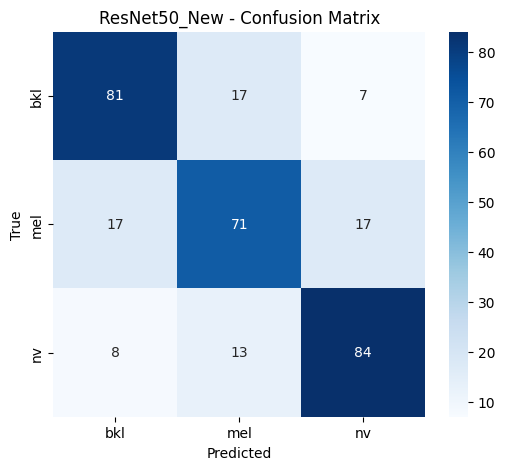

{'Model': 'ResNet50_New',
 'Test Loss': 0.7972161173820496,
 'Test Accuracy': 0.7396825551986694,
 'Macro Precision': 0.7482996727345691,
 'Macro Recall': 0.7492063492063492,
 'Macro F1': 0.748608431521351,
 'Weighted F1': 0.7486084315213509,
 'Saved Model': '/content/drive/MyDrive/Dermo dataset /archive/resnet50_vs_efficientnetb3_extended/ResNet50_New_final.keras'}

In [46]:
# ============================================
# NEW EXPERIMENT CELL 8: Run ResNet50
# ============================================
result_resnet50_new = train_and_evaluate_new("ResNet50_New", build_resnet50_new)
result_resnet50_new

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 1470 validated image filenames belonging to 3 classes.
Found 315 validated image filenames belonging to 3 classes.
Found 315 validated image filenames belonging to 3 classes.
\nEfficientNetB3_New - Stage 1
Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.4775 - loss: 1.4061
Epoch 1: val_loss improved from None to 0.91621, saving model to /content/drive/MyDrive/Dermo dataset /archive/resnet50_vs_efficientnetb3_extended/best_EfficientNetB3_New.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dermo dataset /archive/resnet50_vs_efficientnetb3_extended/best_EfficientNetB3_New.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 81s 773ms/step - accuracy: 0.5238 - loss: 1.2775 - val_accuracy: 0.6032 - val_loss: 0.9162 - learning_rate: 0.0010
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.5824 - loss: 1.0664
Epoch 2: val_loss improved from 0.91621 to 0.87381, saving model to /content/drive/MyDrive/Dermo da

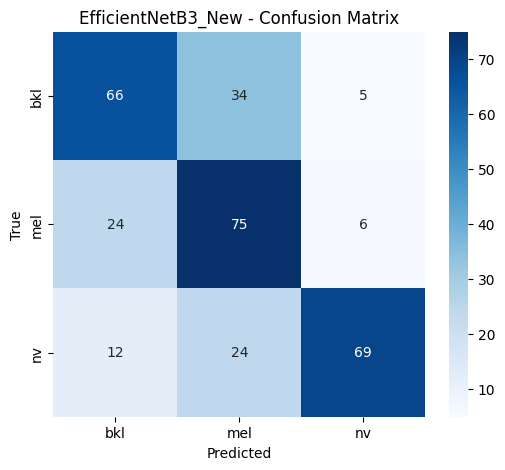

{'Model': 'EfficientNetB3_New',
 'Test Loss': 0.8884040713310242,
 'Test Accuracy': 0.6603174805641174,
 'Macro Precision': 0.691156199321834,
 'Macro Recall': 0.6666666666666666,
 'Macro F1': 0.671293068735524,
 'Weighted F1': 0.671293068735524,
 'Saved Model': '/content/drive/MyDrive/Dermo dataset /archive/resnet50_vs_efficientnetb3_extended/EfficientNetB3_New_final.keras'}

In [47]:
# ============================================
# NEW EXPERIMENT CELL 9: Run EfficientNetB3
# ============================================
result_effb3_new = train_and_evaluate_new("EfficientNetB3_New", build_efficientnetb3_new)
result_effb3_new

In [48]:
# ============================================
# NEW EXPERIMENT CELL 10: Compare results
# ============================================
comparison_new = pd.DataFrame([
    result_resnet50_new,
    result_effb3_new
])

comparison_new = comparison_new.sort_values(
    by=["Test Accuracy", "Macro F1"],
    ascending=False
).reset_index(drop=True)

display(comparison_new)

comparison_new_path = os.path.join(SAVE_DIR_NEW, "resnet50_vs_efficientnetb3_results.csv")
comparison_new.to_csv(comparison_new_path, index=False)

print("Saved comparison:", comparison_new_path)

,Model,Test Loss,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Saved Model
0,ResNet50_New,0.797216,0.739683,0.748300,0.749206,0.748608,0.748608,/content/drive/MyDrive/Dermo dataset /archive/...
1,EfficientNetB3_New,0.888404,0.660317,0.691156,0.666667,0.671293,0.671293,/content/drive/MyDrive/Dermo dataset /archive/...


Saved comparison: /content/drive/MyDrive/Dermo dataset /archive/resnet50_vs_efficientnetb3_extended/resnet50_vs_efficientnetb3_results.csv
